In [1]:
# prompt: give the code to upload the csv in collab using pandas

from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv("breast-cancer-wisconsin-data.csv")


Saving breast-cancer-wisconsin-data.csv to breast-cancer-wisconsin-data.csv


In [2]:
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df['diagnosis'] = LE.fit_transform(df['diagnosis'])
df.head()

# standadization
df.iloc[:, 2:].head()

from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
df.iloc[:, 2:] = SS.fit_transform(df.iloc[:, 2:])
df.iloc[:, 2:].head()

Y = df["diagnosis"]
X = df.iloc[:, 2:]

# data partition
# data partition
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test   = train_test_split(X,Y,test_size=0.3)

# model fitting --> logic

# predictions -->
# metrics --> training acc and test acc
# cross validation

# step5: Model fitting
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()

logreg.fit(X_train,Y_train)

# predictions
Y_pred_train = logreg.predict(X_train)
Y_pred_test = logreg.predict(X_test)

from sklearn.metrics import accuracy_score

ac1 = accuracy_score(Y_train,Y_pred_train)
print("Training Accuracy score:", ac1.round(2))

ac2 = accuracy_score(Y_test,Y_pred_test)
print("Test Accuracy score:", ac2.round(2))

#==============================================================
# cross validation --> validation set appraoch
#==============================================================
import numpy as np
train_acc = []
test_acc = []

for i in range(1,101,1):
    X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=i)
    logreg.fit(X_train,Y_train)
    Y_pred_train = logreg.predict(X_train)
    Y_pred_test = logreg.predict(X_test)
    train_acc.append(accuracy_score(Y_train,Y_pred_train))
    test_acc.append(accuracy_score(Y_test,Y_pred_test))

print("Cross validation training accuracy:",np.mean(train_acc).round(2))
print("Cross validation test accuracy:",np.mean(test_acc).round(2))



Training Accuracy score: 0.99
Test Accuracy score: 0.97
Cross validation training accuracy: 0.99
Cross validation test accuracy: 0.97


In [5]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,Y_train)

# predictions
Y_pred_train = knn.predict(X_train)
Y_pred_test = knn.predict(X_test)

from sklearn.metrics import accuracy_score

ac1 = accuracy_score(Y_train,Y_pred_train)
print("Training Accuracy score:", ac1.round(2))

ac2 = accuracy_score(Y_test,Y_pred_test)
print("Test Accuracy score:", ac2.round(2))


Training Accuracy score: 0.97
Test Accuracy score: 0.95


In [ ]:
from sklearn.metrics import log_loss

loss1 = log_loss(Y_train,Y_pred_train)
print("Training Log loss:", loss1.round(2))

loss2 = log_loss(Y_test,Y_pred_test)
print("Test Log loss:", loss2.round(2))


Training Log loss: 1.27
Test Log loss: 2.11


In [6]:
#==============================================================
# cross validation --> validation set appraoch
#==============================================================

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

import numpy as np
train_acc = []
test_acc = []

for i in range(1,101,1):
    X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=i)
    knn.fit(X_train,Y_train)
    Y_pred_train = knn.predict(X_train)
    Y_pred_test = knn.predict(X_test)
    train_acc.append(accuracy_score(Y_train,Y_pred_train))
    test_acc.append(accuracy_score(Y_test,Y_pred_test))

print("Cross validation training accuracy:",np.mean(train_acc).round(2))
print("Cross validation test accuracy:",np.mean(test_acc).round(2))

Cross validation training accuracy: 0.98
Cross validation test accuracy: 0.96


In [ ]:
# prompt: using the above cross validation code which i have done and change the different k values from the 5 to 15 and put them in to for loop and calculate the each training and testing accuracy separately

avg_train_acc = []
avg_test_acc = []

train_acc = []
test_acc = []

for k in range(5, 16):
  knn = KNeighborsClassifier(n_neighbors=k)

  for i in range(1, 101):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=i)
    knn.fit(X_train, Y_train)
    Y_pred_train = knn.predict(X_train)
    Y_pred_test = knn.predict(X_test)
    train_acc.append(accuracy_score(Y_train, Y_pred_train))
    test_acc.append(accuracy_score(Y_test, Y_pred_test))

  print(f"k: {k}")
  print("Cross validation training accuracy:", np.mean(train_acc).round(2))
  avg_train_acc.append(np.mean(train_acc).round(2))
  print("Cross validation test accuracy:", np.mean(test_acc).round(2))
  avg_test_acc.append(np.mean(test_acc).round(2))
  print()






k: 5
Cross validation training accuracy: 0.98
Cross validation test accuracy: 0.96

k: 6
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 7
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 8
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 9
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 10
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 11
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 12
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 13
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 14
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96

k: 15
Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96



In [ ]:
avg_train_acc

[0.98, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97, 0.97]

In [ ]:
avg_test_acc

[0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96]

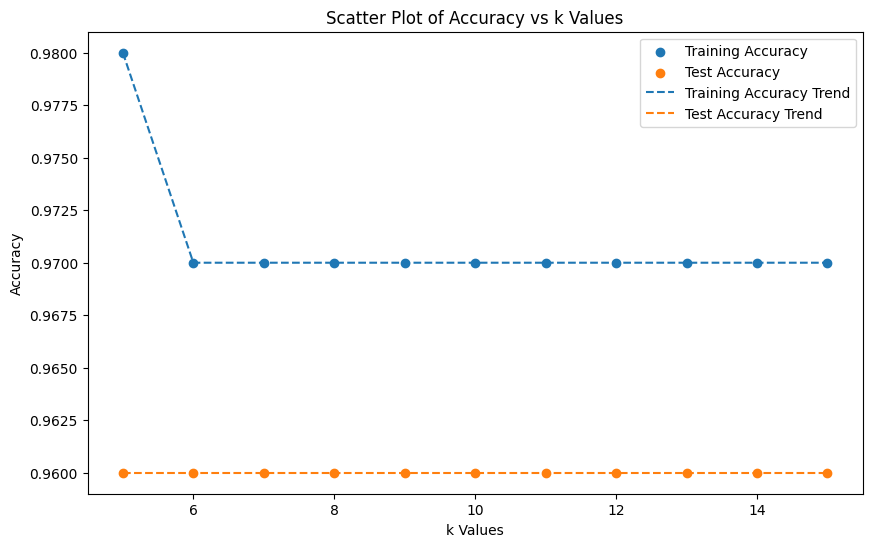

In [ ]:
# prompt: construct a scatter plot using all k values as on x-axis and avg_train_acc and avg_test_acc on y-axis and plot in between them

import matplotlib.pyplot as plt

k_values = range(5, 16)

plt.figure(figsize=(10, 6))
plt.scatter(k_values, avg_train_acc, label="Training Accuracy")
plt.scatter(k_values, avg_test_acc, label="Test Accuracy")

plt.xlabel("k Values")
plt.ylabel("Accuracy")
plt.title("Scatter Plot of Accuracy vs k Values")

plt.plot(k_values, avg_train_acc, linestyle="--", label="Training Accuracy Trend")
plt.plot(k_values, avg_test_acc, linestyle="--", label="Test Accuracy Trend")

plt.legend()
plt.show()


In [8]:
# prompt: give the code to import the principal component analysis

from sklearn.decomposition import PCA
pca = PCA()
PC = pca.fit_transform(X)

In [12]:
PC = pd.DataFrame(PC)
PC

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411424,2.159370,-0.398407,-0.157118,-0.877402,...,0.096515,0.068850,0.084519,-0.175256,-0.151020,-0.201503,-0.252585,-0.033914,0.045648,-0.047169
1,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028656,0.013358,0.240988,-0.711905,1.106995,...,-0.077327,-0.094578,-0.217718,0.011290,-0.170510,-0.041129,0.181270,0.032624,-0.005687,-0.001868
2,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541452,-0.668166,0.097374,0.024066,0.454275,...,0.311067,-0.060309,-0.074291,0.102762,0.171158,0.004735,0.049569,0.047026,0.003146,0.000751
3,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429911,1.059565,-1.405440,-1.116975,...,0.434193,-0.203266,-0.124105,0.153430,0.077496,-0.275225,0.183462,0.042484,-0.069295,-0.019937
4,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936213,0.636376,-0.263805,0.377704,...,-0.116545,-0.017650,0.139454,-0.005332,0.003062,0.039254,0.032168,-0.034786,0.005038,0.021214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,6.439315,-3.576817,2.459487,1.177314,-0.074824,-2.375193,-0.596130,-0.035471,0.987929,0.256989,...,0.006888,-0.067000,0.088590,0.107898,0.219520,-0.122900,0.159198,0.009853,0.007119,-0.001415
565,3.793382,-3.584048,2.088476,-2.506028,-0.510723,-0.246710,-0.716326,-1.113360,-0.105207,-0.108632,...,-0.009802,0.019563,-0.055405,0.086135,0.001197,0.065889,-0.068512,-0.023575,-0.027486,-0.010419
566,1.256179,-1.902297,0.562731,-2.089227,1.809991,-0.534447,-0.192758,0.341887,0.393917,0.520877,...,-0.036592,0.063352,-0.200312,-0.044819,0.002429,0.007095,-0.023691,-0.002578,0.006706,0.003770
567,10.374794,1.672010,-1.877029,-2.356031,-0.033742,0.567936,0.223082,-0.280239,-0.542035,-0.089296,...,0.140648,-0.042478,0.168820,-0.195969,0.377830,-0.198192,-0.027409,-0.068086,-0.084163,-0.023783


In [16]:
PC.iloc[:,0].var()

13.304990794374541

In [18]:
for i in range(0,30,1):
  print(PC.iloc[:,i].var())

13.304990794374541
5.701374603726136
2.8229101550062308
1.984127517730202
1.6516332423301177
1.20948223980297
0.6764088817009067
0.4774562546895079
0.41762878210781657
0.3513108748817336
0.294433153491165
0.2616211613661209
0.2417824213283139
0.15728614921759318
0.0943006956010556
0.08000340447737667
0.059503613530431786
0.05271142221014783
0.04956470021298156
0.03121426055306632
0.030025663090428315
0.027487711338904323
0.024383691354591005
0.01808679398430534
0.015508527134418556
0.00819203711760727
0.006912612579184537
0.0015921360011976586
0.0007501214127186303
0.0001332790566639992


In [20]:
d1 = pd.DataFrame(pca.explained_variance_ratio_)
d1

,0
0,0.442720
1,0.189712
2,0.093932
3,0.066021
4,0.054958
5,0.040245
6,0.022507
7,0.015887
8,0.013896
9,0.011690


In [29]:
X_new = PC.iloc[:,0:8]

In [24]:
X_new.shape

(569, 10)

In [30]:
#==============================================================
# cross validation --> validation set appraoch
#==============================================================
import numpy as np
train_acc = []
test_acc = []

for i in range(1,101,1):
    X_train,X_test,Y_train,Y_test=train_test_split(X_new,Y,test_size=0.3,random_state=i)
    logreg.fit(X_train,Y_train)
    Y_pred_train = logreg.predict(X_train)
    Y_pred_test = logreg.predict(X_test)
    train_acc.append(accuracy_score(Y_train,Y_pred_train))
    test_acc.append(accuracy_score(Y_test,Y_pred_test))

print("Cross validation training accuracy:",np.mean(train_acc).round(2))
print("Cross validation test accuracy:",np.mean(test_acc).round(2))



Cross validation training accuracy: 0.98
Cross validation test accuracy: 0.97


In [26]:
#==============================================================
# cross validation --> validation set appraoch
#==============================================================

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

import numpy as np
train_acc = []
test_acc = []

for i in range(1,101,1):
    X_train,X_test,Y_train,Y_test=train_test_split(X_new,Y,test_size=0.3,random_state=i)
    knn.fit(X_train,Y_train)
    Y_pred_train = knn.predict(X_train)
    Y_pred_test = knn.predict(X_test)
    train_acc.append(accuracy_score(Y_train,Y_pred_train))
    test_acc.append(accuracy_score(Y_test,Y_pred_test))

print("Cross validation training accuracy:",np.mean(train_acc).round(2))
print("Cross validation test accuracy:",np.mean(test_acc).round(2))

Cross validation training accuracy: 0.97
Cross validation test accuracy: 0.96
